Pequeño proyecto de redes neuronales convolucionales para aprendizaje de perros y gatos.

In [1]:
%pip install -r requirements.txt #Instalar dependencias

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Importando librerias
import tensorflow as tf
import tensorflow_datasets as tfds      #Bancos de imagenes
import matplotlib.pyplot as plt         #Mostrar los datos
import cv2
import numpy as np
from tensorflow.keras.callbacks import TensorBoard #Tabla de estadisticas de redes neuronales

I0000 00:00:1791512721.248129   17348 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791512721.290083   17348 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791512722.772700   17348 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1791512724.482039   17348 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50

I0000 00:00:1791512725.095093   17454 tf_record_dataset_op.cc:398] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


,image,label
0,,1 (dog)
1,,1 (dog)
2,,1 (dog)
3,,0 (cat)
4,,1 (dog)

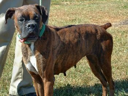
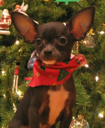
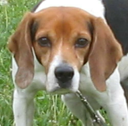
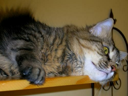
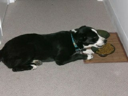

In [3]:
datos, metadatos = tfds.load('cats_vs_dogs', as_supervised = True, with_info = True);
#print(datos, metadatos)                                        #Existe nadamas para mostrar datos
tfds.as_dataframe(datos['train'].take(5), metadatos)           #Existe nadamas para mostrar datos

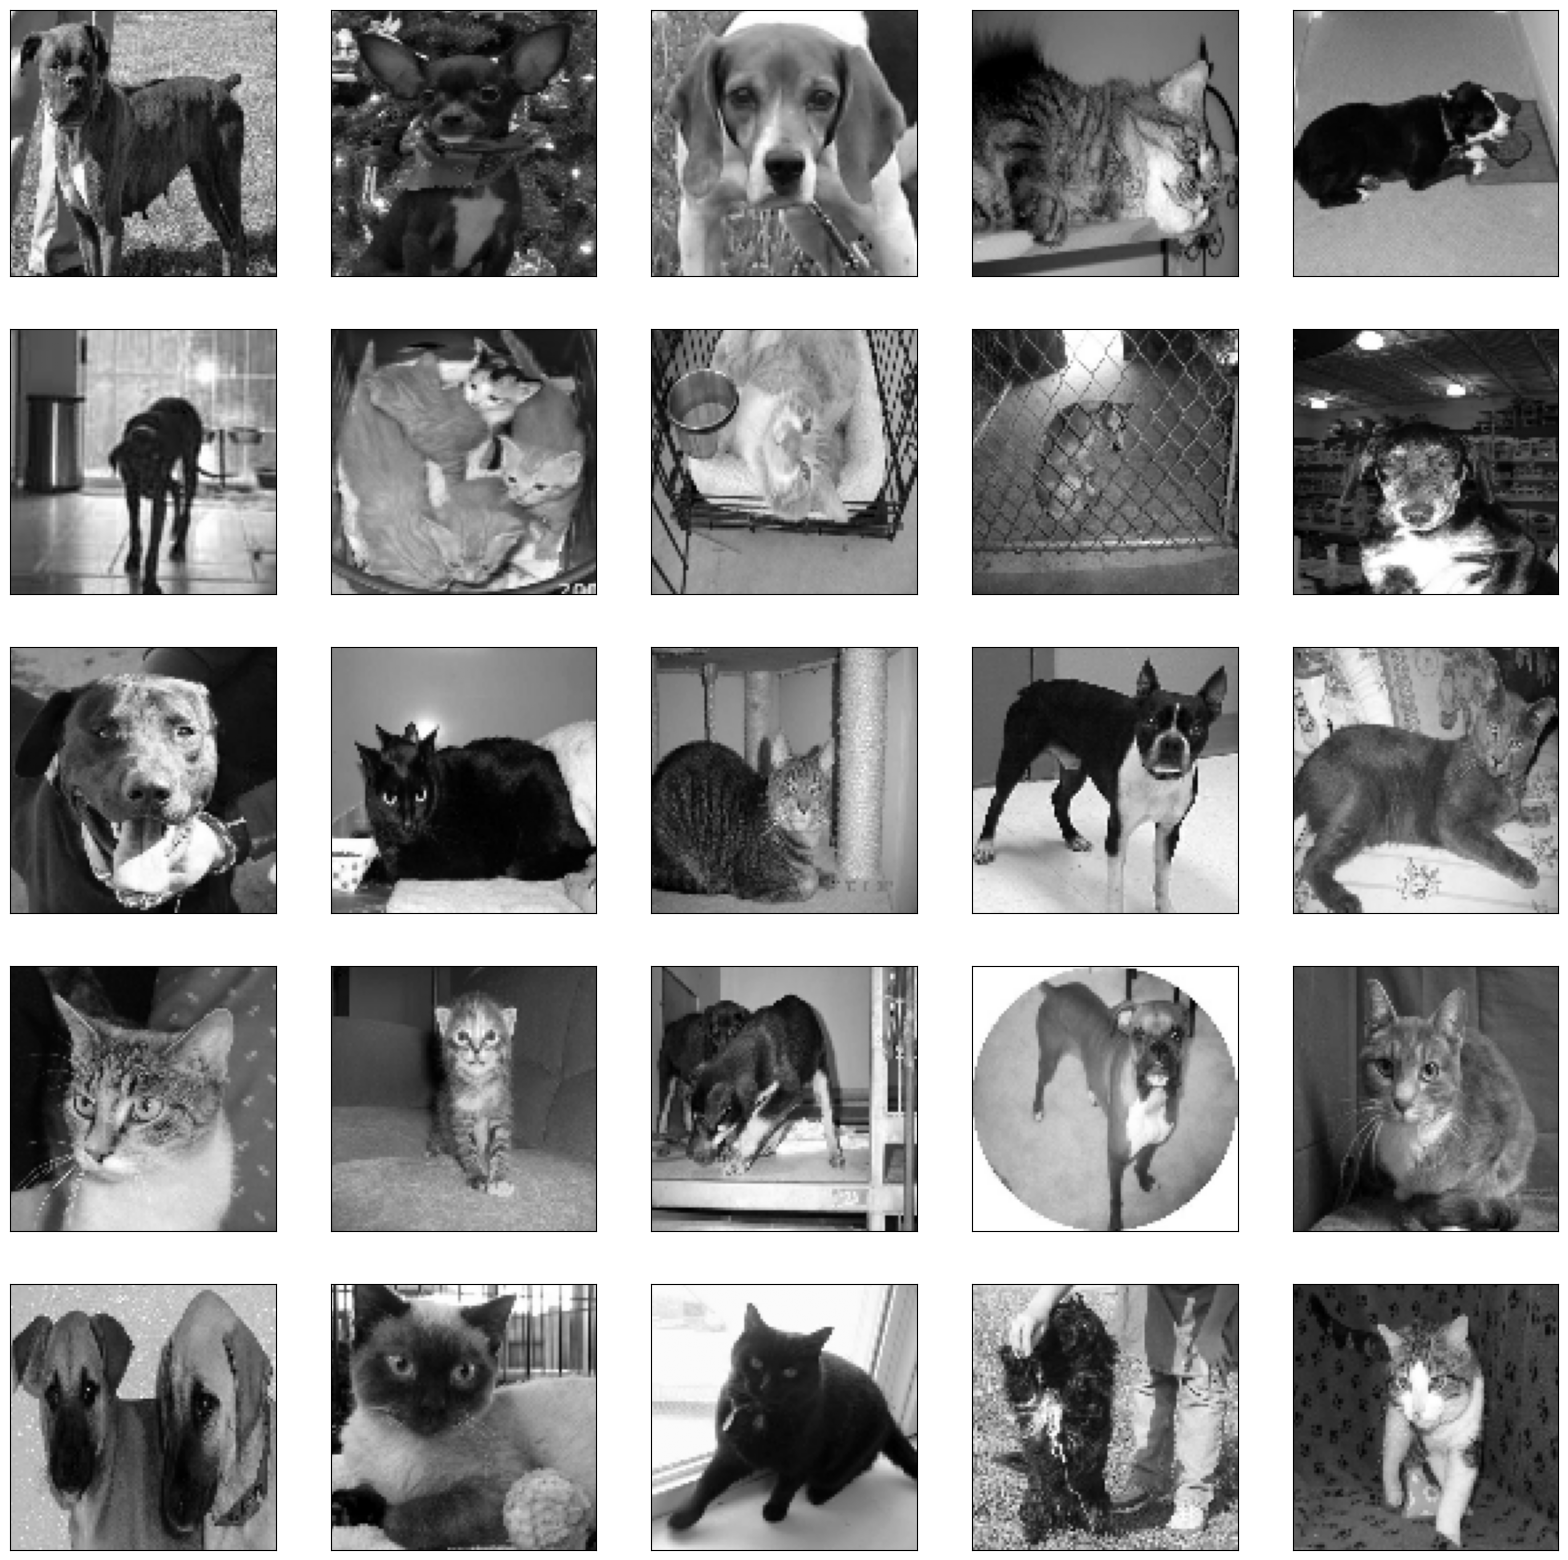

In [4]:
plt.figure(figsize=(20,20)) #Dimensiones
Tamano_img = 100
for i, (imagen , etiqueta) in enumerate(datos['train'].take(25)): #traer los datos
    plt.subplot(5,5,1+i) #Matriz 5x5
    plt.xticks([]) #limpiando las imagenes en x, (cosas de matplotlib)
    plt.yticks([]) #limpiando las imagenes en y, (cosas de matplotlib)
    imagen = imagen.numpy()
    imagen = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY) #Cambiar de color gris
    imagen = cv2.resize(imagen,(Tamano_img, Tamano_img))        #Redimensionar las imagenes a 200*200 px
    plt.imshow(imagen, cmap='gray') #Mostrar los datos y cmap para un solo canal

In [5]:
datos_entrenamiento = []
for i, (imagen, etiqueta) in enumerate(datos['train']): #todos los datos
    imagen = imagen.numpy()
    imagen = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)           #Cambiar de color gris
    imagen = cv2.resize(imagen,(Tamano_img, Tamano_img))        #Redimensionar las imagenes a 100*100 px
    imagen.reshape(100,100,1)                                   #Es una imagen de 100*100 * 1 canal de color
    datos_entrenamiento.append([imagen, etiqueta])

In [6]:
X = [] #Imagenes de entrada (Pixeles)
Y = [] #Etiquetas (Si es perro o gato)
import numpy as np
for imagen, etiqueta in datos_entrenamiento:
    X.append(imagen)
    Y.append(etiqueta)
X = np.array(X).astype(float)/255
Y = np.array(Y)
#X.shape         #23262 entradas (imagenes) -> 100 * 100 pixeles
#Y.shape         #23262 entradas (1 para perro y 0 para gato)

Modelos sin aumento de datos (No recomendado)

In [7]:
modeloDenso = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(100,100,1)), #Recibiria datos de 100 * 100, osea 1000 entradas y un solo canal de colores.
    tf.keras.layers.Dense(150, activation="relu"), # Consta de 150 neuronas y relu es que deja pasar los valores positivos sin cambios y convierte los valores negativos en cero.
    tf.keras.layers.Dense(150, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

modeloCNN = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(100,100,1)), 
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"), 
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation="relu"), 
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

modeloCNN2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(100,100,1)), 
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"), 
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation="relu"), 
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(250, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

/usr/local/python/3.14.2/lib/python3.14/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/python/3.14.2/lib/python3.14/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compilación de los modelos

In [ ]:
modeloDenso.compile(optimizer = "adam",
                    loss= "binary_crossentropy",
                    metrics = ["accuracy"]
                    )
    

modeloCNN.compile(optimizer = "adam",
                    loss= "binary_crossentropy",
                    metrics = ["accuracy"]
                    )


modeloCNN2.compile(optimizer = "adam",
                    loss= "binary_crossentropy",
                    metrics = ["accuracy"]
                    )

Entrenamiento neuronal

In [ ]:
TensorBoardDenso = TensorBoard(log_dir="logs/denso")
modeloDenso.fit(X, Y, batch_size=32, validation_split=0.15, epochs=100, callbacks=[TensorBoardDenso])